In [1]:
import pandas as pd

# Load the news data
# The '../' tells Python to look outside the notebooks folder for the data folder
df = pd.read_csv('../data/raw_analyst_ratings.csv')

# Show the first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw_analyst_ratings.csv'

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

# This looks "up" one level and shows all folders
print("Folders found:", os.listdir('..'))

# This looks inside the data folder
try:
    print("Files inside data folder:", os.listdir('../data'))
except:
    print("Could not find the 'data' folder at all!")

Folders found: ['.git', 'data', 'notebooks', 'pip', 'scripts', 'src', 'tests', 'venv']
Files inside data folder: ['raw']


In [3]:
import pandas as pd

# We added '/raw/' between 'data' and the filename
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# This should now show your data!
df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
# This tells you the total rows and columns
print(f"There are {df.shape[0]} articles in this dataset.")

There are 1407328 articles in this dataset.


Matplotlib is building the font cache; this may take a moment.


NameError: name 'plt' is not defined

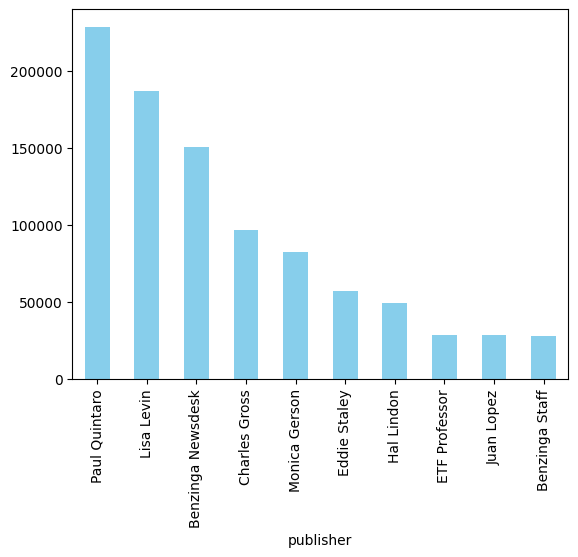

In [5]:
# This shows the top 10 publishers
publisher_counts = df['publisher'].value_counts()
publisher_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Active News Publishers')
plt.ylabel('Number of Articles')
plt.show()

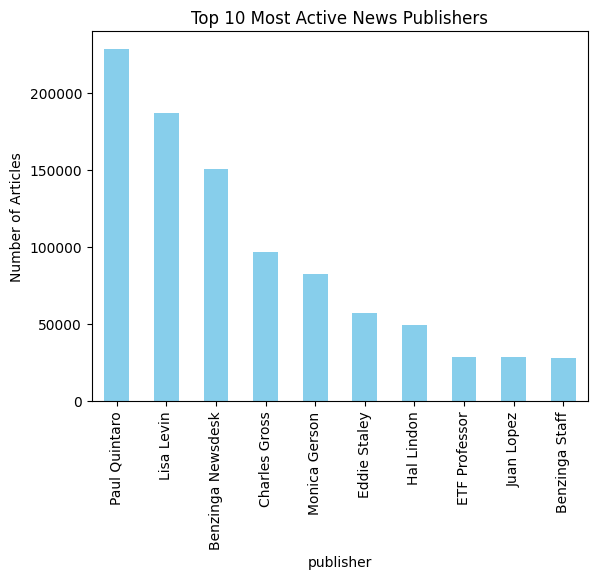

In [7]:
# This shows the top 10 publishers
publisher_counts = df['publisher'].value_counts()
publisher_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Active News Publishers')
plt.ylabel('Number of Articles')
plt.show()

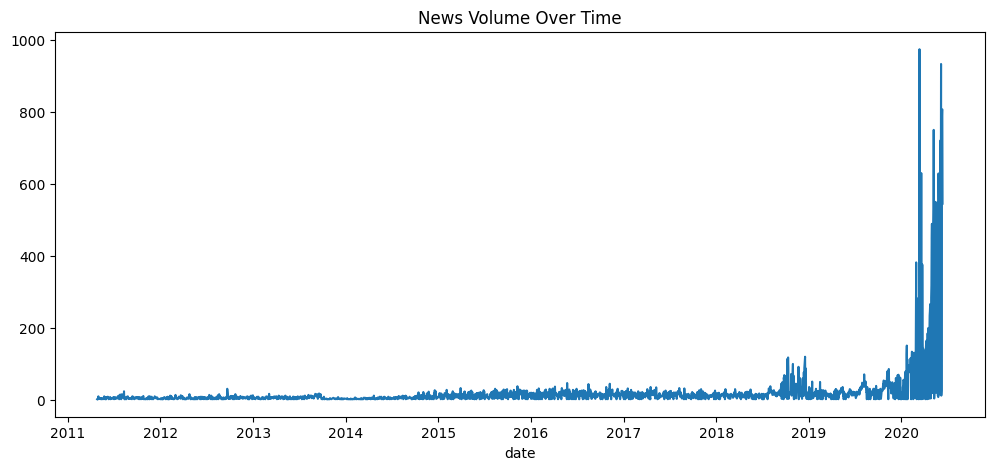

In [8]:
# Convert the 'date' column so Python understands time
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Plot how many articles were published per day
df['date'].dt.date.value_counts().sort_index().plot(figsize=(12,5))
plt.title('News Volume Over Time')
plt.show()

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Initialize the tool
analyzer = SentimentIntensityAnalyzer()

In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Initialize the tool
analyzer = SentimentIntensityAnalyzer()

# 2. Define a function to get the 'compound' score
def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

# 3. Apply it to a sample of 10,000 headlines (to save time)
# Later you can do the whole thing
df_sample = df.head(10000).copy()
df_sample['sentiment_score'] = df_sample['headline'].apply(get_sentiment)

# 4. See the results
df_sample[['headline', 'sentiment_score']].head()

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


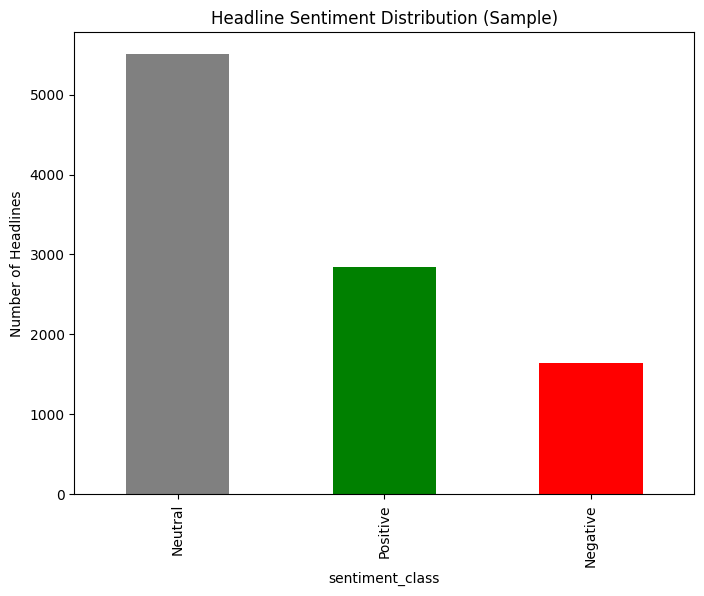

In [11]:
# 1. Categorize the scores
def label_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

df_sample['sentiment_class'] = df_sample['sentiment_score'].apply(label_sentiment)

# 2. Draw a chart to see the overall "Mood"
plt.figure(figsize=(8,6))
df_sample['sentiment_class'].value_counts().plot(kind='bar', color=['gray', 'green', 'red'])
plt.title('Headline Sentiment Distribution (Sample)')
plt.ylabel('Number of Headlines')
plt.show()